# 문제 2 — 회전 행렬 구현과 합성 순서 검증

축별 회전 행렬 `rot_x`, `rot_y`, `rot_z` 를 직접 구현하고

1. 회전축 성분이 보존된다는 사실을 3D 로 확인하고,
2. **합성 순서가 바뀌면 결과가 달라진다**(행렬 곱은 교환법칙이 성립하지 않는다)는 것을
   행렬과 그림 양쪽으로 보이고,
3. 행렬식이 1 이어야 하는 이유(반사가 아니라 회전임을 보장)를 반사 행렬과 비교하고,
4. 문제 1 의 `skew` 로 **로드리게스 공식**을 구현해 `rot_z` 와 일치하는지 검증합니다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rodrigues, rot_x, rot_y, rot_z
from src.vectors import det, skew          # 문제 1 에서 만든 함수를 재사용

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 한글 라벨이 깨지지 않도록 폰트 지정 (실제 등록된 이름을 찾아서 사용, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK JP", "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break

plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0, alpha=1.0, labels=None):
    """회전 행렬 R 의 세 열을 x(빨강)·y(초록)·z(파랑) 축으로 그린다."""
    origin = np.asarray(origin, dtype=float)
    colors = ["r", "g", "b"]
    names = labels if labels else ["x", "y", "z"]
    for i in range(3):
        v = R[:, i] * scale
        ax.quiver(*origin, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(origin + v * 1.12), names[i], color=colors[i], fontsize=9)


def setup_axes(ax, title, lim=1.3):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 2-1. 축별 회전 행렬과 `rot_z(90도)` 검증

오른손 좌표계에서 각 축 회전 행렬은 다음과 같습니다.

$$R_x(\theta)=\begin{bmatrix}1&0&0\\0&\cos\theta&-\sin\theta\\0&\sin\theta&\cos\theta\end{bmatrix},\quad
R_y(\theta)=\begin{bmatrix}\cos\theta&0&\sin\theta\\0&1&0\\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}$$

$R_y$ 만 부호가 뒤집혀 보이는 이유는, 오른손 규칙에서 y축 회전이
$z \rightarrow x$ 방향으로 돌기 때문입니다.

$R_z(90^\circ)$ 를 $(1,0,0)$ 에 적용하면 $(\cos 90^\circ, \sin 90^\circ, 0) = (0,1,0)$ 이 되어야 합니다.

In [2]:
Rz90 = rot_z(np.deg2rad(90.0))
print("rot_z(90도) =\n", Rz90)

p = np.array([1.0, 0.0, 0.0])
p_rot = Rz90 @ p
print("\n(1,0,0) -> ", p_rot)

print("\nrot_x(90도) =\n", rot_x(np.pi / 2))
print("\nrot_y(90도) =\n", rot_y(np.pi / 2))

rot_z(90도) =
 [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

(1,0,0) ->  [0. 1. 0.]

rot_x(90도) =
 [[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]

rot_y(90도) =
 [[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]


In [3]:
# --- 검증 ---
ok = check("rot_z(90도) @ (1,0,0) == (0,1,0)", np.allclose(p_rot, [0.0, 1.0, 0.0]))
ok &= check("rot_x(90도) @ (0,1,0) == (0,0,1)",
            np.allclose(rot_x(np.pi / 2) @ [0, 1, 0], [0, 0, 1]))
ok &= check("rot_y(90도) @ (0,0,1) == (1,0,0)",
            np.allclose(rot_y(np.pi / 2) @ [0, 0, 1], [1, 0, 0]))
ok &= check("0도 회전은 단위행렬", np.allclose(rot_z(0.0), np.eye(3)))
ok &= check("R(theta) @ R(-theta) == I", np.allclose(rot_z(0.7) @ rot_z(-0.7), np.eye(3)))
ok &= check("회전은 길이를 보존", np.isclose(np.linalg.norm(p_rot), np.linalg.norm(p)))
print("\n2-1 전체 통과:", ok)

[PASS] rot_z(90도) @ (1,0,0) == (0,1,0)
[PASS] rot_x(90도) @ (0,1,0) == (0,0,1)
[PASS] rot_y(90도) @ (0,0,1) == (1,0,0)
[PASS] 0도 회전은 단위행렬
[PASS] R(theta) @ R(-theta) == I
[PASS] 회전은 길이를 보존

2-1 전체 통과: True


## 2-2. 축별 회전 3D 시각화 — 회전축 성분은 보존된다

임의의 점 하나를 각 축 기준으로 0 ~ 360도 돌리면 궤적은 **회전축에 수직인 원**이 됩니다.
즉 회전축 방향 성분은 전혀 변하지 않습니다.
이것이 $R_x$ 의 첫 행/열, $R_y$ 의 둘째, $R_z$ 의 셋째가 단위벡터인 이유입니다.

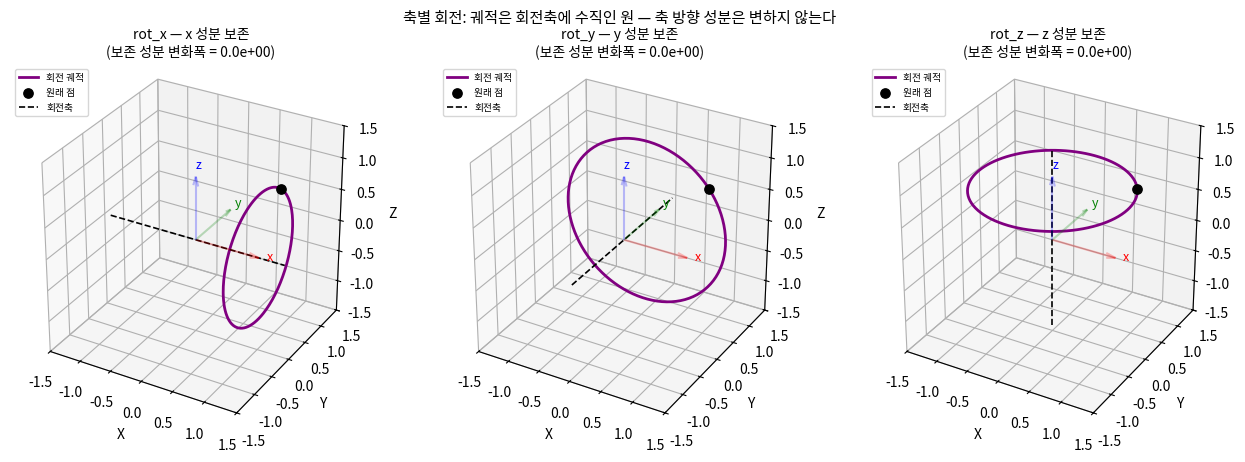

In [4]:
p0 = np.array([1.0, 0.6, 0.8])
angles = np.linspace(0, 2 * np.pi, 200)

fig = plt.figure(figsize=(13, 4.4))
info = []
for k, (name, maker, axis_vec, keep) in enumerate([
    ("rot_x — x 성분 보존", rot_x, [1, 0, 0], 0),
    ("rot_y — y 성분 보존", rot_y, [0, 1, 0], 1),
    ("rot_z — z 성분 보존", rot_z, [0, 0, 1], 2),
]):
    traj = np.array([maker(t) @ p0 for t in angles])
    spread = traj[:, keep].max() - traj[:, keep].min()
    info.append((name, spread))

    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    setup_axes(ax, name + "\n(보존 성분 변화폭 = {:.1e})".format(spread), lim=1.5)
    draw_frame(ax, scale=1.0, alpha=0.25)
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color="purple", lw=2, label="회전 궤적")
    ax.scatter(*p0, color="k", s=45, label="원래 점")
    av = np.array(axis_vec, dtype=float) * 1.4
    ax.plot([-av[0], av[0]], [-av[1], av[1]], [-av[2], av[2]], "k--", lw=1.2, label="회전축")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("축별 회전: 궤적은 회전축에 수직인 원 — 축 방향 성분은 변하지 않는다", fontsize=11)
fig.tight_layout()
plt.show()

In [5]:
# --- 검증 ---
ok = True
for name, spread in info:
    ok &= check(name + " : 보존 성분 변화폭 {:.2e} < 1e-12".format(spread), spread < 1e-12)

# 궤적 위 모든 점이 원점에서 같은 거리(회전은 길이 보존)
traj = np.array([rot_z(t) @ p0 for t in angles])
radii = np.linalg.norm(traj, axis=1)
ok &= check("회전 궤적의 모든 점이 원점에서 등거리",
            np.allclose(radii, np.linalg.norm(p0)))
print("\n2-2 전체 통과:", ok)

[PASS] rot_x — x 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_y — y 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_z — z 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] 회전 궤적의 모든 점이 원점에서 등거리

2-2 전체 통과: True


## 2-3. 합성 순서가 다르면 결과가 다르다

행렬 곱은 교환법칙이 성립하지 않습니다: $R_y R_z \neq R_z R_y$.

물리적으로도 당연합니다. "먼저 z축으로 90도 돌고 나서 y축으로 90도" 와
"먼저 y축으로 90도 돌고 나서 z축으로 90도" 는 **두 번째 회전이 도는 축이 이미 달라져** 있기 때문입니다.

표기 약속: $R_y R_z \mathbf{p}$ 는 "**$R_z$ 를 먼저**, 그다음 $R_y$" 라는 뜻입니다
(오른쪽 것이 먼저 적용됩니다).

In [6]:
ang = np.deg2rad(90.0)
Ry, Rz = rot_y(ang), rot_z(ang)

A = Ry @ Rz     # z 먼저, 그다음 y
B = Rz @ Ry     # y 먼저, 그다음 z

print("Ry @ Rz (z 먼저) =\n", A)
print("\nRz @ Ry (y 먼저) =\n", B)
print("\n두 결과가 같은가 :", np.allclose(A, B))
print("차이의 최대 절댓값 :", np.max(np.abs(A - B)))

test_p = np.array([1.0, 0.0, 0.0])
print("\n(1,0,0) 을 z->y 순서로 :", A @ test_p)
print("(1,0,0) 을 y->z 순서로 :", B @ test_p)

Ry @ Rz (z 먼저) =
 [[ 0. -0.  1.]
 [ 1.  0.  0.]
 [-0.  1.  0.]]

Rz @ Ry (y 먼저) =
 [[ 0. -1.  0.]
 [ 0.  0.  1.]
 [-1.  0.  0.]]

두 결과가 같은가 : False
차이의 최대 절댓값 : 1.0

(1,0,0) 을 z->y 순서로 : [ 0.  1. -0.]
(1,0,0) 을 y->z 순서로 : [ 0.  0. -1.]


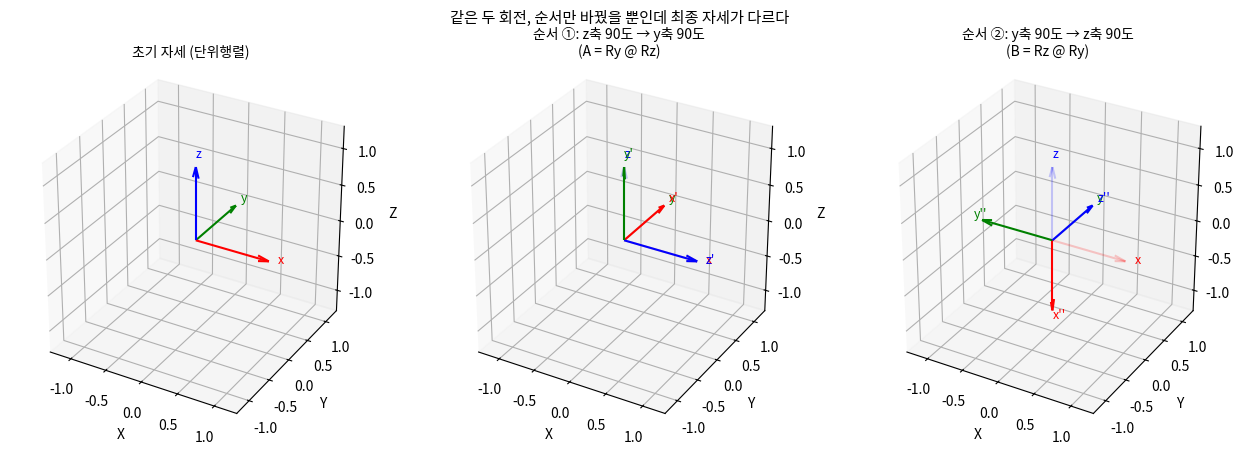

In [7]:
fig = plt.figure(figsize=(13, 4.4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
setup_axes(ax, "초기 자세 (단위행렬)")
draw_frame(ax, np.eye(3))

ax = fig.add_subplot(1, 3, 2, projection="3d")
setup_axes(ax, "순서 ①: z축 90도 → y축 90도\n(A = Ry @ Rz)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, A, labels=["x'", "y'", "z'"])

ax = fig.add_subplot(1, 3, 3, projection="3d")
setup_axes(ax, "순서 ②: y축 90도 → z축 90도\n(B = Rz @ Ry)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, B, labels=["x''", "y''", "z''"])

fig.suptitle("같은 두 회전, 순서만 바꿨을 뿐인데 최종 자세가 다르다", fontsize=11)
fig.tight_layout()
plt.show()

In [8]:
# --- 검증 ---
ok = check("두 합성 결과 행렬이 다르다", not np.allclose(A, B))
ok &= check("같은 축끼리는 순서를 바꿔도 같다 (교환 가능)",
            np.allclose(rot_z(0.3) @ rot_z(0.9), rot_z(0.9) @ rot_z(0.3)))
ok &= check("각도가 0 이면 순서가 무의미", np.allclose(rot_y(0.0) @ rot_z(0.5), rot_z(0.5) @ rot_y(0.0)))
ok &= check("두 결과 모두 회전행렬 (det = 1)",
            np.isclose(det(A), 1.0) and np.isclose(det(B), 1.0))
ok &= check("A 와 B 는 서로 다른 축으로 (1,0,0) 을 보낸다",
            not np.allclose(A @ test_p, B @ test_p))
print("\n2-3 전체 통과:", ok)

[PASS] 두 합성 결과 행렬이 다르다
[PASS] 같은 축끼리는 순서를 바꿔도 같다 (교환 가능)
[PASS] 각도가 0 이면 순서가 무의미
[PASS] 두 결과 모두 회전행렬 (det = 1)
[PASS] A 와 B 는 서로 다른 축으로 (1,0,0) 을 보낸다

2-3 전체 통과: True


## 2-4. 행렬식이 1 이어야 하는 이유 — 회전 vs 반사

직교행렬($R^{\mathsf{T}}R=I$)의 행렬식은 $\pm 1$ 뿐입니다.
$\det(R^{\mathsf{T}}R)=\det(R)^2=\det(I)=1$ 이기 때문입니다.

| 조건 | 의미 |
|---|---|
| $R^{\mathsf{T}}R=I$, $\det R = +1$ | **회전** — 길이·각도·**손 방향(handedness)** 모두 보존 |
| $R^{\mathsf{T}}R=I$, $\det R = -1$ | **반사** — 길이·각도는 보존하지만 좌표계가 뒤집힘 |

행렬식은 부피 배율이자 **부호가 방향(orientation)** 을 나타냅니다.
대각성분이 $(1,1,-1)$ 인 행렬은 z축을 뒤집는 거울이라 $\det=-1$ 이고,
오른손 좌표계를 왼손 좌표계로 바꿔 버립니다.
로봇에서 이런 행렬을 자세로 쓰면 **툴이 거울상으로 뒤집혀** 완전히 잘못된 명령이 됩니다.
그래서 "직교" 만으로는 부족하고 $\det=+1$ 까지 요구합니다 — 이 집합이 $SO(3)$ 입니다.

In [9]:
S = np.diag([1.0, 1.0, -1.0])     # z 를 뒤집는 반사 행렬

rows = [("rot_x(0.7)", rot_x(0.7)), ("rot_y(1.2)", rot_y(1.2)),
        ("rot_z(-0.4)", rot_z(-0.4)), ("반사 diag(1,1,-1)", S)]

print("{:<20}{:>14}{:>16}".format("행렬", "det", "직교 오차"))
print("-" * 50)
for name, Mx in rows:
    orth_err = np.max(np.abs(Mx.T @ Mx - np.eye(3)))
    print("{:<20}{:>14.6f}{:>16.2e}".format(name, det(Mx), orth_err))

# 오른손 규칙이 유지되는지: x축 x y축 == z축 인가
for name, Mx in rows:
    x, y, z = Mx[:, 0], Mx[:, 1], Mx[:, 2]
    print("{:<20} x' x y' == z' ? {}".format(name, np.allclose(np.cross(x, y), z)))

행렬                             det           직교 오차
--------------------------------------------------
rot_x(0.7)                1.000000        2.08e-17
rot_y(1.2)                1.000000        1.11e-16
rot_z(-0.4)               1.000000        2.13e-17
반사 diag(1,1,-1)          -1.000000        0.00e+00
rot_x(0.7)           x' x y' == z' ? True
rot_y(1.2)           x' x y' == z' ? True
rot_z(-0.4)          x' x y' == z' ? True
반사 diag(1,1,-1)      x' x y' == z' ? False


In [10]:
# --- 검증 ---
ok = check("세 회전 행렬의 행렬식이 모두 1",
           all(np.isclose(det(m(t)), 1.0) for m, t in [(rot_x, 0.7), (rot_y, 1.2), (rot_z, -0.4)]))
ok &= check("반사 행렬의 행렬식은 -1", np.isclose(det(S), -1.0))
ok &= check("반사 행렬도 직교이긴 하다", np.allclose(S.T @ S, np.eye(3)))
ok &= check("회전은 오른손 규칙 보존 (x' x y' == z')",
            np.allclose(np.cross(rot_y(1.2)[:, 0], rot_y(1.2)[:, 1]), rot_y(1.2)[:, 2]))
ok &= check("반사는 오른손 규칙을 깬다",
            not np.allclose(np.cross(S[:, 0], S[:, 1]), S[:, 2]))
ok &= check("무작위 회전 100개의 det 가 모두 1",
            all(np.isclose(det(rot_z(t1) @ rot_y(t2) @ rot_x(t3)), 1.0)
                for t1, t2, t3 in rng.uniform(-np.pi, np.pi, (100, 3))))
print("\n2-4 전체 통과:", ok)               

[PASS] 세 회전 행렬의 행렬식이 모두 1
[PASS] 반사 행렬의 행렬식은 -1
[PASS] 반사 행렬도 직교이긴 하다
[PASS] 회전은 오른손 규칙 보존 (x' x y' == z')
[PASS] 반사는 오른손 규칙을 깬다
[PASS] 무작위 회전 100개의 det 가 모두 1

2-4 전체 통과: True


## 2-5. 로드리게스 공식 — `skew` 로 임의 축 회전

단위 축 $\mathbf{k}$ 를 중심으로 $\theta$ 만큼 도는 회전은

$$R = I + \sin\theta\,[\mathbf{k}]_\times + (1-\cos\theta)\,[\mathbf{k}]_\times^2$$

로 쓸 수 있습니다. 문제 1 에서 만든 `skew` 가 그대로 들어갑니다.
축을 $\mathbf{k}=(0,0,1)$ 로 두면 `rot_z` 와 정확히 같아야 합니다.

In [11]:
theta = np.deg2rad(37.0)

R_rod_z = rodrigues([0.0, 0.0, 1.0], theta)
print("rodrigues(z, 37도) =\n", R_rod_z)
print("\nrot_z(37도) =\n", rot_z(theta))
print("\n최대 차이 :", np.max(np.abs(R_rod_z - rot_z(theta))))

# 임의 축
k = np.array([1.0, 2.0, -0.5])
k = k / np.linalg.norm(k)
R_arb = rodrigues(k, theta)
print("\n임의 축 k =", k)
print("rodrigues(k, 37도) =\n", R_arb)
print("\nR @ k =", R_arb @ k, " (축은 회전해도 그대로여야 함)")

# 공식이 skew 로만 구성되는지 직접 확인
K = skew(k)
manual = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
print("\n손으로 조립한 공식과 일치 :", np.allclose(manual, R_arb))

rodrigues(z, 37도) =
 [[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]]

rot_z(37도) =
 [[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]]

최대 차이 : 0.0

임의 축 k = [ 0.436436  0.872872 -0.218218]
rodrigues(k, 37도) =
 [[ 0.836991  0.208037  0.50613 ]
 [-0.054617  0.952056 -0.301009]
 [-0.544485  0.224298  0.808224]]

R @ k = [ 0.436436  0.872872 -0.218218]  (축은 회전해도 그대로여야 함)

손으로 조립한 공식과 일치 : True


In [12]:
# --- 검증 ---
ok = check("rodrigues(z축) == rot_z", np.allclose(R_rod_z, rot_z(theta)))
ok &= check("rodrigues(x축) == rot_x", np.allclose(rodrigues([1, 0, 0], theta), rot_x(theta)))
ok &= check("rodrigues(y축) == rot_y", np.allclose(rodrigues([0, 1, 0], theta), rot_y(theta)))
ok &= check("임의 축 결과가 회전행렬 (det = 1)", np.isclose(det(R_arb), 1.0))
ok &= check("임의 축 결과가 직교", np.allclose(R_arb.T @ R_arb, np.eye(3)))
ok &= check("회전축은 변하지 않는다 (R k == k)", np.allclose(R_arb @ k, k))
ok &= check("정규화 안 된 축을 줘도 같은 결과",
            np.allclose(rodrigues([1.0, 2.0, -0.5], theta), R_arb))
ok &= check("무작위 축 50개 모두 회전행렬",
            all(np.isclose(det(rodrigues(ax, t)), 1.0)
                for ax, t in zip(rng.standard_normal((50, 3)), rng.uniform(-np.pi, np.pi, 50))))
print("\n2-5 전체 통과:", ok)

[PASS] rodrigues(z축) == rot_z
[PASS] rodrigues(x축) == rot_x
[PASS] rodrigues(y축) == rot_y
[PASS] 임의 축 결과가 회전행렬 (det = 1)
[PASS] 임의 축 결과가 직교
[PASS] 회전축은 변하지 않는다 (R k == k)
[PASS] 정규화 안 된 축을 줘도 같은 결과
[PASS] 무작위 축 50개 모두 회전행렬

2-5 전체 통과: True


## 답안 템플릿 정리

In [13]:
summary = """
1. rot_z(90도) 로 변환한 (1,0,0): {p}   (기대값 (0,1,0), 일치 True)

2. 축별 회전 3D 시각화: 위 그림 — 각 회전에서 회전축 방향 성분의 변화폭이
   x: {sx:.1e}, y: {sy:.1e}, z: {sz:.1e} 로 사실상 0 (보존 확인)

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   (Ry@Rz 와 Rz@Ry 의 최대 성분 차이 = {diff:.4f}, 비교 그림은 위 3분할 그림)

4. 세 회전 행렬의 행렬식: 1.0 / 1.0 / 1.0   |   반사 행렬 diag(1,1,-1) 의 행렬식: {ds:.1f}
   - 차이의 의미: 직교행렬의 det 는 +-1 뿐이며, +1 은 회전(손 방향 보존),
     -1 은 반사(좌표계가 거울상으로 뒤집힘)다. det = +1 을 요구해야
     "길이·각도 보존" 에 더해 오른손 좌표계 유지까지 보장된다 -> SO(3).

5. 로드리게스 구현과 rot_z 일치: {rod}  (임의 축에서도 det=1, 직교, R k = k 확인)
""".format(
    p=np.round(Rz90 @ np.array([1.0, 0.0, 0.0]), 6),
    sx=info[0][1], sy=info[1][1], sz=info[2][1],
    diff=float(np.max(np.abs(A - B))),
    ds=det(S),
    rod=bool(np.allclose(R_rod_z, rot_z(theta))),
)
print(summary)


1. rot_z(90도) 로 변환한 (1,0,0): [0. 1. 0.]   (기대값 (0,1,0), 일치 True)

2. 축별 회전 3D 시각화: 위 그림 — 각 회전에서 회전축 방향 성분의 변화폭이
   x: 0.0e+00, y: 0.0e+00, z: 0.0e+00 로 사실상 0 (보존 확인)

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   (Ry@Rz 와 Rz@Ry 의 최대 성분 차이 = 1.0000, 비교 그림은 위 3분할 그림)

4. 세 회전 행렬의 행렬식: 1.0 / 1.0 / 1.0   |   반사 행렬 diag(1,1,-1) 의 행렬식: -1.0
   - 차이의 의미: 직교행렬의 det 는 +-1 뿐이며, +1 은 회전(손 방향 보존),
     -1 은 반사(좌표계가 거울상으로 뒤집힘)다. det = +1 을 요구해야
     "길이·각도 보존" 에 더해 오른손 좌표계 유지까지 보장된다 -> SO(3).

5. 로드리게스 구현과 rot_z 일치: True  (임의 축에서도 det=1, 직교, R k = k 확인)

